# Calling Libraries


In [122]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [123]:
df=pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f'Shape of df is {df.shape}')
display(df.head())
display(df.tail())
display(df.describe())
display(df.info())
col=df.drop(columns=['customerID']).columns
for c in col:
    print(c,end='\n\n')
    print(df[c].value_counts(normalize=True))


Shape of df is (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


None

gender

gender
Male      0.504756
Female    0.495244
Name: proportion, dtype: float64
SeniorCitizen

SeniorCitizen
0    0.837853
1    0.162147
Name: proportion, dtype: float64
Partner

Partner
No     0.516967
Yes    0.483033
Name: proportion, dtype: float64
Dependents

Dependents
No     0.700412
Yes    0.299588
Name: proportion, dtype: float64
tenure

tenure
1     0.087037
72    0.051399
2     0.033792
3     0.028397
4     0.024989
        ...   
28    0.008093
39    0.007951
44    0.007241
36    0.007099
0     0.001562
Name: proportion, Length: 73, dtype: float64
PhoneService

PhoneService
Yes    0.903166
No     0.096834
Name: proportion, dtype: float64
MultipleLines

MultipleLines
No                  0.481329
Yes                 0.421837
No phone service    0.096834
Name: proportion, dtype: float64
InternetService

InternetService
Fiber optic    0.439585
DSL            0.343746
No             0.216669
Name: proportion, dtype: float64
OnlineSecurity

OnlineSecurity
No                 

In [124]:
df['TotalCharges']=df['TotalCharges'].replace(' ',pd.NA)
df.dropna(inplace=True)
df['TotalCharges']=df['TotalCharges'].astype('float')

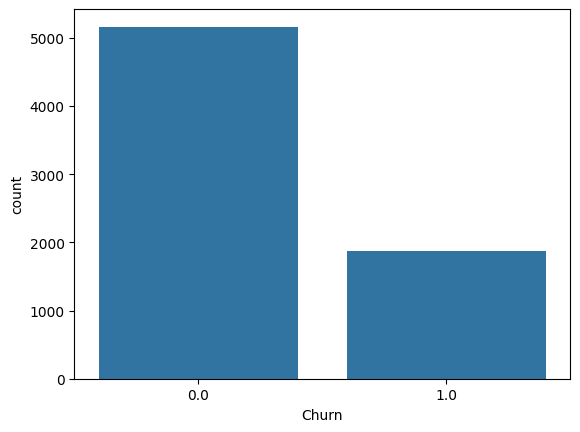

0.7342150170648464


In [145]:
sns.countplot(data=df,x='Churn')
plt.show()
print(len(df[df['Churn']==0])/len(df))

In [126]:
count=df.isna().sum().sum()
count


0

There is no missing value in ```df```

In [127]:
df.duplicated().sum()
df=df.drop(columns=['customerID'])

There is also no duplicates in ```df```

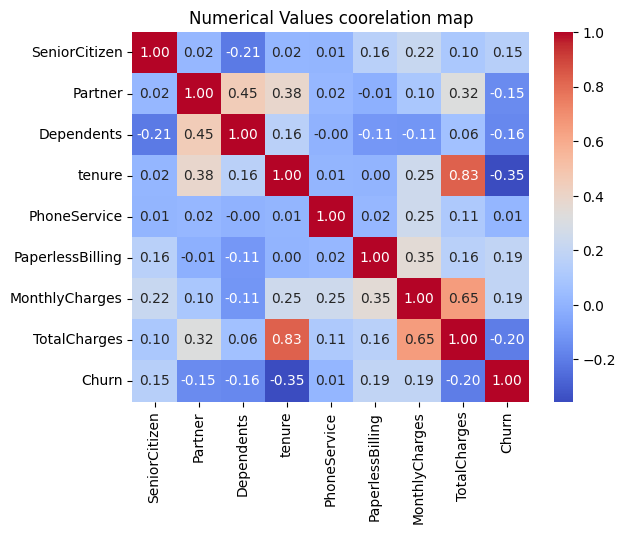

In [128]:
df_num=df.select_dtypes(exclude='object')
sns.heatmap(data=df_num.corr(),cmap='coolwarm',fmt='.2f',annot=True)
plt.title('Numerical Values coorelation map')

plt.show()

In [130]:
from sklearn.preprocessing import MinMaxScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
num_col=df.select_dtypes(exclude='object').columns
cat_col=df.select_dtypes(include='object').columns
ct=ColumnTransformer(
    transformers=[('num_col',MinMaxScaler(),num_col),
     ('cat_col',OneHotEncoder(),cat_col)]
)
df_transformed=ct.fit_transform(df)
col_name=ct.get_feature_names_out()
for i in range(len(col_name)):
    col_name[i]=col_name[i][9:]
df=pd.DataFrame(df_transformed,columns=col_name,index=df.index)


In [ ]:
display(df.head())
df.shape

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,gender_Female,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.0,1.0,0.0,0.000000,0.0,1.0,0.115423,0.001275,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.464789,1.0,0.0,0.385075,0.215867,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0.0,0.0,0.0,0.014085,1.0,1.0,0.354229,0.010310,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.619718,0.0,0.0,0.239303,0.210241,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.014085,1.0,1.0,0.521891,0.015330,1.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


(7032, 42)

In [134]:
from sklearn.model_selection import train_test_split
X=df.drop(columns=['Churn'])
y=df['Churn']
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.3,stratify=y,random_state=43)


In [135]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV
from xgboost import XGBClassifier

In [163]:
def free_loop(old,new,threshold=1e-3):
    l=[]
    for k,item in old.items():
        if not isinstance(old[k][0],str):
            sum1=np.median(old[k])
            sum2=np.median(new[k])
            l.append(abs(sum1-sum2)< threshold)
    return all(l)

def workflow(model,param):
    for i in range(50):
        rv=RandomizedSearchCV(estimator=model,param_distributions=param,n_iter=10,random_state=42,scoring='roc_auc',n_jobs=-1,cv=5)
        rv.fit(x_train,y_train)
        print('Finished RandomizedSearchCV')
        param_final={}
        param_init=rv.best_params_
        for key,value in param_init.items():
            if isinstance(value,str):
                liste=[value]
            elif value<0.99 or key=='C':
                liste=[value*0.8,value,value*1.2]
            elif 1<=value<=90:
                liste=[value-1,value,value+1,]
            else:
                liste=[value/2,value,value*2]
            param_final[key]=liste
        if free_loop(param,param_final):
            break
        param=param_final
    print('StartedGridSearchCV')
    cv=GridSearchCV(estimator=model,param_grid=param_final,scoring='roc_auc',n_jobs=-1,cv=5)
    cv.fit(x_train,y_train)
    return cv.best_estimator_
param_grid_svc = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'gamma': [0.0001, 0.001, 0.01, 0.1, 1],
    'kernel': ['rbf', 'poly', 'sigmoid'],
    'degree': [2, 3, 4, 5],     
    'coef0': [0, 0.1, 0.5, 1]   
}
svc=workflow(SVC(),param_grid_svc)

        

Finished RandomizedSearchCV
Finished RandomizedSearchCV
Finished RandomizedSearchCV
Finished RandomizedSearchCV
Finished RandomizedSearchCV
Finished RandomizedSearchCV
Finished RandomizedSearchCV
Finished RandomizedSearchCV
Finished RandomizedSearchCV
Finished RandomizedSearchCV
Finished RandomizedSearchCV
Finished RandomizedSearchCV
Finished RandomizedSearchCV
Finished RandomizedSearchCV
Finished RandomizedSearchCV
Finished RandomizedSearchCV
Finished RandomizedSearchCV
Finished RandomizedSearchCV
Finished RandomizedSearchCV
Finished RandomizedSearchCV
Finished RandomizedSearchCV
Finished RandomizedSearchCV
Finished RandomizedSearchCV
Finished RandomizedSearchCV
Finished RandomizedSearchCV
Finished RandomizedSearchCV
Finished RandomizedSearchCV
Finished RandomizedSearchCV
Finished RandomizedSearchCV
Finished RandomizedSearchCV
Finished RandomizedSearchCV
StartedGridSearchCV


In [164]:
from sklearn.metrics import classification_report,roc_auc_score
svc.fit(x_train,y_train)
y_pred=svc.predict(x_test)
print('Classification Report:',classification_report(y_test,y_pred))
print('Area Under Curve score:',roc_auc_score(y_test,y_pred))

Classification Report:               precision    recall  f1-score   support

         0.0       0.85      0.89      0.87      1549
         1.0       0.65      0.57      0.61       561

    accuracy                           0.81      2110
   macro avg       0.75      0.73      0.74      2110
weighted avg       0.80      0.81      0.80      2110

Area Under Curve score: 0.7291939253546363


In [ ]:
param_grid_xgb = {
    "n_estimators": [200, 400, 800],
    "max_depth": [3, 4, 6, 8],
    "learning_rate": [0.001, 0.01, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0, 0.1, 0.5, 1],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [0.1, 1, 5, 10],
    "min_child_weight": [1, 3, 5, 7]
}

xgb=workflow(XGBClassifier(),param_grid_xgb)